一つの加工対象csvファイルに対して、そのデータ数を設定した数まで圧縮するコード

In [11]:
# セル1: ライブラリのインポート
import tkinter as tk
from tkinter import filedialog
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

# グラフの日本語文字化け防止
plt.rcParams['font.family'] = ['Times New Roman', 'MS Gothic']

print("セル1: ライブラリのインポートと設定が完了しました。")

セル1: ライブラリのインポートと設定が完了しました。


In [12]:
# セル2: 設定セクション
ROWS_TO_SKIP = 70
FILE_ENCODING = 'cp932'
TARGET_COLUMN = '(1)HA-V05'

# 理想の出力行数（Excelで重くならない目標行数）
TARGET_ROW_COUNT = 10000 
# 平滑化の強さ（数値を大きくすると線がより滑らかになります）
SMOOTHING_FACTOR = 2.0 

# ==========================================
# ★ 追加・変更：時間軸によるデータ範囲の指定（秒）
# ==========================================
# 抽出を開始・終了する時間を「秒」で入力します。
# 制限しない（最初から最後までにする）場合は None にしてください。
START_TIME_SEC = 2.0     # 例: 2.0秒から開始
END_TIME_SEC = 5.0      # 例: 5.0秒で終了（最後まで抽出する場合は None）

PLOT_ORIGINAL = True  # グラフに元の波形（薄いグレー）も描画するかどうか

print("セル2: 設定の読み込みが完了しました。")

セル2: 設定の読み込みが完了しました。


In [13]:
# セル3: ファイル選択
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

print("ファイル選択ダイアログを開いています...（画面の裏に隠れている場合があります）")
filepath = filedialog.askopenfilename(
    title="解析したいCSVファイル（1つ）を選択してください",
    filetypes=[("CSV files", "*.csv"), ("All files", "*.*")]
)

if not filepath:
    print("キャンセルされました。")
else:
    print(f"選択されたファイル: {filepath}")

ファイル選択ダイアログを開いています...（画面の裏に隠れている場合があります）
選択されたファイル: C:/Users/0uh2j/OneDrive/Desktop/実験データ2026/本実験データ/202606_本実験温度データ/csv/0.5-2.0mmデータ/1.0mm/210℃/035_210℃_080_1.0mm.csv


In [14]:
# セル4: データ処理（読み込み・切り出し・移動平均・間引き）
if not 'filepath' in locals() or not filepath:
    print("エラー: セル3でファイルを選択してください。")
else:
    # サンプリング周期の読み取り
    actual_sampling_rate_hz = 100000.0  
    try:
        with open(filepath, 'r', encoding=FILE_ENCODING, errors='ignore') as f:
            for _ in range(50):
                line = f.readline()
                if not line: break
                if 'サンプリング周期' in line:
                    match = re.search(r'(\d+)\s*μs', line)
                    if match:
                        us_val = float(match.group(1))
                        if us_val > 0:
                            actual_sampling_rate_hz = 1000000.0 / us_val
                            break
    except Exception as e:
        print(f" -> [警告] ヘッダー読み取りエラー: {e}")

    print("データを読み込んでいます（数秒〜数十秒かかります）...")
    try:
        df = pd.read_csv(
            filepath, 
            skiprows=ROWS_TO_SKIP, 
            encoding=FILE_ENCODING, 
            encoding_errors='ignore', 
            on_bad_lines='skip', 
            nrows=None, # ★全データを一旦読み込む
            low_memory=False
        )
        
        if TARGET_COLUMN not in df.columns:
            print(f" -> [エラー] 列 '{TARGET_COLUMN}' が見つかりません。")
        else:
            df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors='coerce').fillna(0)
            
            print("時間列の作成中...")
            df['Time (s)'] = np.arange(0, len(df)) * (1.0 / actual_sampling_rate_hz)
            
            # ==========================================
            # ★ 追加：時間軸ベースでのデータの切り出し
            # ==========================================
            start_t = START_TIME_SEC if START_TIME_SEC is not None else df['Time (s)'].min()
            end_t = END_TIME_SEC if END_TIME_SEC is not None else df['Time (s)'].max()
            
            print(f"指定された時間範囲 ({start_t}s 〜 {end_t}s) でデータを抽出中...")
            df = df[(df['Time (s)'] >= start_t) & (df['Time (s)'] <= end_t)].reset_index(drop=True)
            
            if len(df) == 0:
                print(" -> [エラー] 指定された時間範囲にデータが存在しません。セル2の設定を見直してください。")
            else:
                # 抽出したデータの範囲内で間引きステップを計算
                total_rows = len(df)
                step = max(1, total_rows // TARGET_ROW_COUNT)
                
                # ウィンドウサイズの自動最適化
                WINDOW_SIZE = int(step * SMOOTHING_FACTOR)
                if WINDOW_SIZE % 2 == 0:
                    WINDOW_SIZE += 1
                WINDOW_SIZE = max(3, WINDOW_SIZE)
                
                print(f"自動最適化: 抽出後データ数={total_rows:,}行, 間引きステップ={step}行, 移動平均ウィンドウサイズ={WINDOW_SIZE}点")
                
                # 隣接平均の計算
                print("隣接平均を計算中...")
                smoothed_col_name = f'{TARGET_COLUMN}_smoothed'
                df[smoothed_col_name] = df[TARGET_COLUMN].rolling(window=WINDOW_SIZE, center=True, min_periods=1).mean()
                
                print(f"データを約1万行にするため、{step}行 ごとに圧縮（間引き）します...")
                df_compressed = df.iloc[::step].copy()
                
                print(f"圧縮完了: 圧縮後のデータ数 {len(df_compressed):,}行")
            
    except Exception as e:
        print(f"ファイル読み込み・処理エラー: {e}")

データを読み込んでいます（数秒〜数十秒かかります）...
時間列の作成中...
指定された時間範囲 (2.0s 〜 5.0s) でデータを抽出中...
自動最適化: 抽出後データ数=1,000,002行, 間引きステップ=100行, 移動平均ウィンドウサイズ=201点
隣接平均を計算中...
データを約1万行にするため、100行 ごとに圧縮（間引き）します...
圧縮完了: 圧縮後のデータ数 10,001行


★ 約1万行の圧縮済みデータを出力しました: C:/Users/0uh2j/OneDrive/Desktop/実験データ2026/本実験データ/202606_本実験温度データ/csv/0.5-2.0mmデータ/1.0mm/210℃\035_210℃_080_1.0mm_smoothed_10k.csv
グラフを描画中...
★ グラフ画像を出力しました: C:/Users/0uh2j/OneDrive/Desktop/実験データ2026/本実験データ/202606_本実験温度データ/csv/0.5-2.0mmデータ/1.0mm/210℃\035_210℃_080_1.0mm_smoothed_10k_graph.png


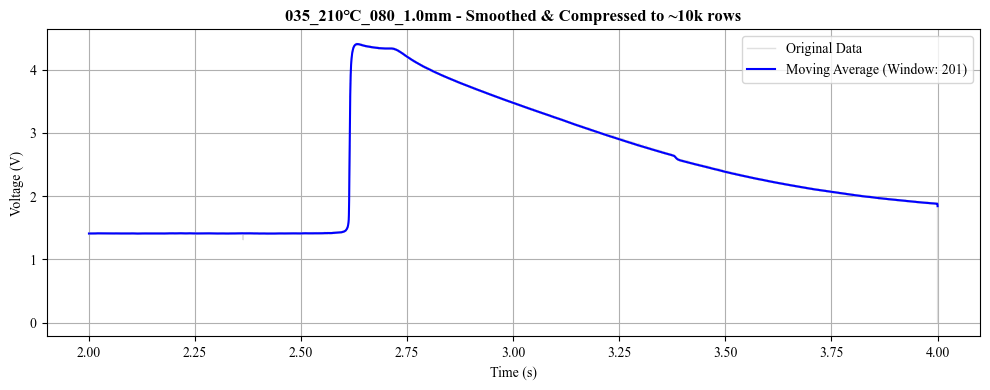

In [ ]:
# セル5: 結果の出力（CSV & グラフ）
if not 'df' in locals() or not 'df_compressed' in locals():
    print("エラー: セル4のデータ処理を先に完了させてください。")
elif len(df) > 0: # データが存在する場合のみ実行
    output_dir = os.path.dirname(filepath)
    base_name = os.path.basename(filepath).replace('.csv', '')
    
    # CSV出力
    csv_out_path = os.path.join(output_dir, f"{base_name}_smoothed_10k.csv")
    output_df = df_compressed[['Time (s)', smoothed_col_name]]
    output_df.to_csv(csv_out_path, index=False, encoding='utf-8-sig')
    print(f"★ 約1万行の圧縮済みデータを出力しました: {csv_out_path}")
    
    # グラフの作成と保存
    print("グラフを描画中...")
    fig, ax = plt.subplots(figsize=(10, 4))
    
    if PLOT_ORIGINAL:
        # 間引き前の全データを使って正確なノイズ幅を描画
        ax.plot(df['Time (s)'], df[TARGET_COLUMN], color='lightgray', alpha=0.7, linewidth=1.0, label='Original Data')
        
    # 青線は間引き後のデータでサクサク描画
    ax.plot(df_compressed['Time (s)'], df_compressed[smoothed_col_name], color='blue', linewidth=1.5, label=f'Moving Average (Window: {WINDOW_SIZE})')
    
    ax.set_title(f"{base_name} - Smoothed & Compressed to ~10k rows", fontsize=12, fontweight='bold')
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Voltage (V)")
    ax.legend(loc='upper right')
    ax.grid(True)
    fig.tight_layout()
    
    img_out_path = os.path.join(output_dir, f"{base_name}_smoothed_10k_graph.png")
    fig.savefig(img_out_path, dpi=150)
    print(f"★ グラフ画像を出力しました: {img_out_path}")
    
    plt.show()